# Model Training & Evaluation

## Objective
Train multiple machine learning models to predict customer churn and evaluate them with a focus on recall to minimize missed churners.

In [98]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score

In [99]:
import pandas as pd
import numpy as np

In [100]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [101]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values
df = df.dropna()

In [102]:
df = df.drop("customerID", axis=1)

In [103]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [104]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [105]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

In [106]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [109]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [110]:
y_train.value_counts()
y_train_res.value_counts()

Churn
0    4130
1    4130
Name: count, dtype: int64

In [111]:
lr = LogisticRegression(class_weight="balanced", max_iter=1000)

lr.fit(X_train_res, y_train_res)   # training on SMOTE data

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [112]:
y_pred_lr = lr.predict(X_test)   # NOT X_train_res

In [113]:
print(y_test.unique())

[0 1]


In [114]:
print(y_pred_lr[:10])

[0 1 0 0 0 1 0 0 1 0]


In [115]:
print("Logistic Regression")
print("Recall:", recall_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression
Recall: 0.7192513368983957
Precision: 0.5114068441064639
F1 Score: 0.5977777777777777
[[776 257]
 [105 269]]


In [116]:
dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [117]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [118]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

c:\Users\vansh\customer-churn-prediction-pipeline\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:35:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [119]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
})

results

,Model,Recall,Precision,F1 Score
0,Logistic Regression,0.719251,0.511407,0.597778
1,Decision Tree,0.491979,0.494624,0.493298
2,Random Forest,0.489305,0.626712,0.549550
3,XGBoost,0.548128,0.589080,0.567867


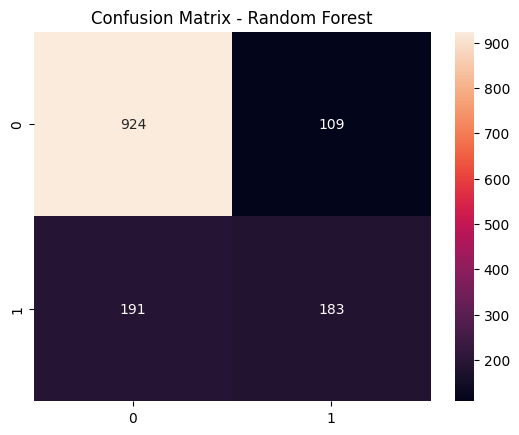

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [121]:
y_probs = rf.predict_proba(X_test)[:, 1]

In [122]:
y_pred_custom = (y_probs > 0.3).astype(int)

In [123]:
print("Recall:", recall_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))

Recall: 0.7272727272727273
Precision: 0.5190839694656488


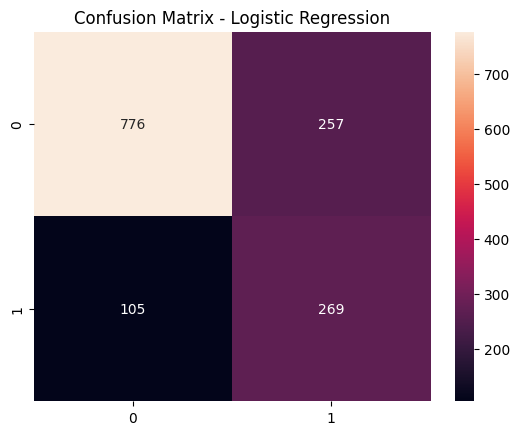

In [126]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [127]:
y_probs = lr.predict_proba(X_test)[:, 1]

y_pred_custom = (y_probs > 0.3).astype(int)


In [128]:
print("Recall:", recall_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))

Recall: 0.8716577540106952
Precision: 0.4399460188933873


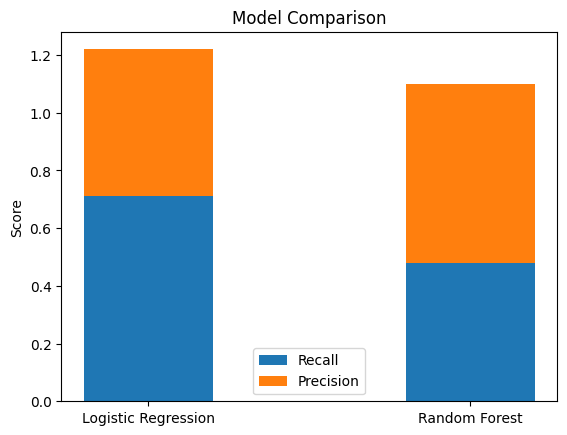

In [129]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
recall = [0.71, 0.48]
precision = [0.51, 0.62]

x = range(len(models))

plt.bar(x, recall, width=0.4, label="Recall")
plt.bar(x, precision, width=0.4, bottom=recall, label="Precision")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()

plt.show()

## Final Model Comparison

Logistic Regression outperforms Random Forest in terms of recall, which is the primary metric for this problem.

It captures more churners (higher true positives) and significantly reduces missed churners (false negatives).

Although Random Forest has higher precision, it fails to identify a large number of churners,


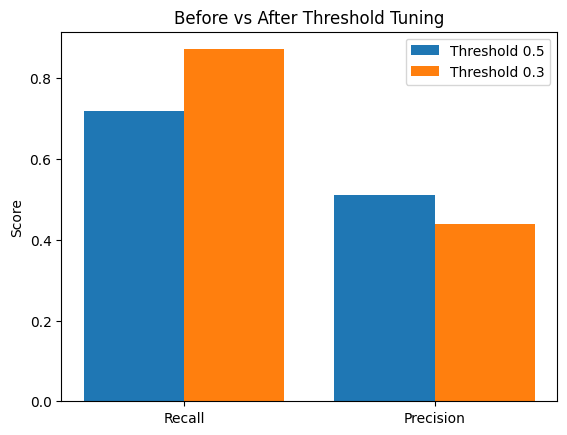

In [130]:
import matplotlib.pyplot as plt

labels = ["Recall", "Precision"]

before = [recall_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr)]
after = [recall_score(y_test, y_pred_custom), precision_score(y_test, y_pred_custom)]

x = range(len(labels))

plt.bar(x, before, width=0.4, label="Threshold 0.5")
plt.bar([i + 0.4 for i in x], after, width=0.4, label="Threshold 0.3")

plt.xticks([i + 0.2 for i in x], labels)
plt.ylabel("Score")
plt.title("Before vs After Threshold Tuning")
plt.legend()

plt.show()

## Threshold Tuning Impact

Lowering the decision threshold increased recall significantly, allowing the model to identify more churners.

However, this came at the cost of reduced precision, meaning more non-churn customers were incorrectly classified as churners.

This trade-off is acceptable because the business goal is to minimize missed churners.


## Business Interpretation

- The model prioritizes identifying customers likely to churn
- Higher recall ensures fewer churners are missed
- Some false positives are acceptable as they allow proactive retention strategies
- Missing a churner is more costly than incorrectly targeting a loyal customer